# Inicialización del entorno de trabajo

In [15]:
import warnings
import pandas as pd
import pyreadr
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
 )
from sklearn.metrics import roc_curve, precision_recall_curve
from IPython.display import Markdown, display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import display
import time
import cProfile
import pstats
import io
from copy import deepcopy
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in reduce')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.preprocessing._encoders')

def columnas_categoricas(dataframe, excluir=None):
    excluir = set(excluir or [])
    cols = []
    for col in dataframe.columns:
        if col in excluir:
            continue
        dtype = dataframe[col].dtype
        if (
            pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)
            or pd.api.types.is_bool_dtype(dtype)
        ):
            cols.append(col)
    return cols

resultado = pyreadr.read_r('listings.RData')
df = list(resultado.values())[0]
print(f"Dimensiones iniciales del dataset: {df.shape}")

numericas = df.select_dtypes(include=['number']).columns.tolist()
categoricas = columnas_categoricas(df)

print(f"Variables numéricas detectadas: {len(numericas)}")
print(f"Variables categóricas detectadas: {len(categoricas)}")
print('Ejemplo variables numéricas:', numericas[:10])
print('Ejemplo variables categóricas:', categoricas[:10])

limpio = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
 )
df['price'] = pd.to_numeric(limpio, errors='coerce')
print('Conversión de price completada.')

Dimensiones iniciales del dataset: (171748, 80)
Variables numéricas detectadas: 33
Variables categóricas detectadas: 47
Ejemplo variables numéricas: ['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm']
Ejemplo variables categóricas: ['listing_url', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 'host_name', 'host_since']
Conversión de price completada.


In [12]:
df = df.replace([np.inf, -np.inf], np.nan)

faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

print("=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===")
print(f"Columnas con vacíos: {len(faltantes)}")
print("Top 10 columnas con más vacíos:")
print(faltantes.head(10))
print("\n" + "=" * 40 + "\n")

porcentajes = (faltantes / len(df)) * 100
print("=== PORCENTAJE DE VACÍOS (TOP 10) ===")
print((porcentajes.head(10).round(2)).astype(str) + " %")

df = df.dropna(subset=['price'])
df = df.dropna(axis=1, how='all')

numericas = df.select_dtypes(include=['number']).columns.tolist()
if 'price' in numericas:
    numericas.remove('price')

categoricas = columnas_categoricas(df, excluir=['price'])

imputador_num = SimpleImputer(strategy='median')
imputador_cat = SimpleImputer(strategy='constant', fill_value='Sin Dato')

df[numericas] = imputador_num.fit_transform(df[numericas])
df[categoricas] = imputador_cat.fit_transform(df[categoricas])

print('Filas sin precio eliminadas y faltantes imputados.')
print('Total de nulos restantes:', df.isnull().sum().sum())
print('Dimensiones luego de limpieza:', df.shape)

=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===
Columnas con vacíos: 23
Top 10 columnas con más vacíos:
calendar_updated                171748
price                            95502
estimated_revenue_l365d          95502
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
dtype: int64


=== PORCENTAJE DE VACÍOS (TOP 10) ===
calendar_updated                100.0 %
price                           55.61 %
estimated_revenue_l365d         55.61 %
neighbourhood_group_cleansed    29.51 %
review_scores_value             23.48 %
review_scores_location          23.48 %
review_scores_checkin           23.48 %
review_scores_accuracy          23.47 %
review_scores_communication     23.47 %
review_scores_cleanliness       23.47 %
dtype: str
Filas sin precio eliminadas y faltantes impu

# \\\ Predicción de modelos de los precios de las casas //
#         - Empresa *SmartStay Advisors* -
# Maquinas Vectoriales de Soporte (SVM)

*Integrantes de la investigación:*
- Vianka Castro - 23201
- Ricardo Godinez - 23247
- Felipe Aguilar - 23195

Para esta nueva entrega hemos decidido proporcionarles un nuevo modelo operativo llamado Maquinas Vectoriales de Soporte para ayudarles a estimar los precios competitivos, las propiedades con baja ocupación, factores que influyen en la compra y diseño de estrategias basada en los datos para aumentar la rentabilidad de su empresa. 

Seguiremos utilizando el mismo dataset listings.RData que se nos fue proporcionado en la entrega anterior, el cual contiene información detallada sobre las propiedades listadas en la plataforma de SmartStay Advisors. Este dataset incluye variables como el precio, la ubicación, el número de habitaciones, la ocupación, entre otros factores relevantes para el análisis.

Por último les brindaremos una comparativa entre este modelo y los trabajados anteriormente para que puedan evaluar cuál de ellos se adapta mejor a sus necesidades y objetivos comerciales.

## 1. Comenzamos con la limpieza de datos y el uso de las mismas variables de entrenamiento y de prueba que fueron utilizadas en entregas anteriores. 

In [14]:
# 0. CREAR VARIABLE RESPUESTA (MISMA LÓGICA DE ENTREGAS ANTERIORES)
q1, q2 = df['price'].astype(float).quantile([1/3, 2/3])

df['categoria_precio'] = pd.cut(
    df['price'].astype(float),
    bins=[-float('inf'), q1, q2, float('inf')],
    labels=['Economica', 'Intermedia', 'Cara'],
    include_lowest=True
)

df['es_economica'] = (df['categoria_precio'] == 'Economica').astype(int)
df['es_intermedia'] = (df['categoria_precio'] == 'Intermedia').astype(int)
df['es_cara'] = (df['categoria_precio'] == 'Cara').astype(int)

print('Puntos de corte usados para categoria_precio:')
print(f'q1 (33%): {q1:.2f} | q2 (66%): {q2:.2f}')
print(df[['categoria_precio', 'es_economica', 'es_intermedia', 'es_cara']].head())

# 1. ELIMINAR NULOS Y DEFINIR X E Y
filas_sanas = df['categoria_precio'].notna()
df_limpio = df[filas_sanas].copy()

columnas_a_botar = [
    'price', 'categoria_precio', 'es_economica', 'es_intermedia', 'es_cara',
    'id', 'scrape_id', 'host_id', 'last_scraped', 'calendar_last_scraped',
    'first_review', 'last_review',
    'latitude', 'longitude',
    'neighbourhood_group_cleansed',
    'host_verifications'
 ]

X = df_limpio.drop(columns=[col for col in columnas_a_botar if col in df_limpio.columns])
X = X.replace([np.inf, -np.inf], np.nan)

# En variables binarias t/f mal codificadas, removemos las columnas de soporte.
columnas_falsas = [col for col in X.columns if col.endswith('_f') and len(X[col].unique()) <= 2]
X = X.drop(columns=columnas_falsas, errors='ignore')

columnas_forzar_numero = ['accommodates', 'bathrooms', 'bedrooms', 'beds']
for col in columnas_forzar_numero:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas_crudas = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
categoricas = [col for col in categoricas_crudas if X[col].nunique(dropna=True) < 50]
X[categoricas] = X[categoricas].astype(str)

Y_strata = df_limpio['categoria_precio']
Y_dicotomicas = df_limpio[['es_economica', 'es_intermedia', 'es_cara']]

# 2. MISMA SEPARACIÓN 70/30 USADA EN NOTEBOOKS PREVIOS
X_train_clf, X_test_clf, Y_train_dico, Y_test_dico = train_test_split(
    X, Y_dicotomicas, test_size=0.3, random_state=42, stratify=Y_strata
)

preprocesador_clf = ColumnTransformer(
    transformers=[
        ('numeros', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numericas),
        ('textos', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=True))
        ]), categoricas)
    ]
)

print('\nResumen del split aplicado:')
print('test_size=0.3 | random_state=42 | stratify=Y_strata')
print(f'X_train_clf: {X_train_clf.shape} | X_test_clf: {X_test_clf.shape}')

dist_train = Y_strata.loc[X_train_clf.index].value_counts(normalize=True).sort_index()
dist_test = Y_strata.loc[X_test_clf.index].value_counts(normalize=True).sort_index()
print('\nDistribución relativa en train:')
print(dist_train.round(4))
print('\nDistribución relativa en test:')
print(dist_test.round(4))

Puntos de corte usados para categoria_precio:
q1 (33%): 143.00 | q2 (66%): 268.00
  categoria_precio  es_economica  es_intermedia  es_cara
0        Economica             1              0        0
1       Intermedia             0              1        0
2        Economica             1              0        0
3       Intermedia             0              1        0
4        Economica             1              0        0

Resumen del split aplicado:
test_size=0.3 | random_state=42 | stratify=Y_strata
X_train_clf: (53372, 67) | X_test_clf: (22874, 67)

Distribución relativa en train:
categoria_precio
Economica     0.3369
Intermedia    0.3299
Cara          0.3332
Name: proportion, dtype: float64

Distribución relativa en test:
categoria_precio
Economica     0.3369
Intermedia    0.3299
Cara          0.3332
Name: proportion, dtype: float64


Para esta fase, procedimos a separar nuestro conjunto de datos en entrenamiento (70%) y prueba (30%). Con el objetivo de garantizar una comparación rigurosa y justa frente a los modelos construidos en laboratorios anteriores, replicamos exactamente la misma semilla de aleatoriedad (`random_state=42`) y utilizamos la misma variable objetivo multiclase para aplicar el muestreo estratificado (`stratify`). Esto asegura que los modelos anteriores y este SVM se entrenen y evalúen sobre la misma partición de registros.

## 2. Exploración de datos y transformaciones para el modelo SVM

Siguiendo la guía conceptual de SVM (margen máximo, sensibilidad a escala y uso de kernels), esta sección valida por qué necesitamos transformar los datos antes de entrenar.

Transformaciones aplicadas y su justificación:
- Estandarización (`StandardScaler`) en variables numéricas: evita que variables con magnitudes grandes dominen el hiperplano.
- Imputación de nulos: mediana en numéricas y moda en categóricas para no perder observaciones.
- Codificación `OneHotEncoder` en categóricas: SVM requiere una representación numérica.
- Eliminación de columnas problemáticas o redundantes: reduce ruido y colinealidad innecesaria.

A continuación se imprimen estadísticas y gráficos de respaldo para dejar trazabilidad del preprocesamiento.

=== EXPLORACIÓN INICIAL PARA SVM ===
Observaciones limpias: 76,246
Cantidad de variables predictoras: 67

Resumen de price:
count    76246.00
mean       750.51
std       4250.61
min          8.00
25%        120.00
50%        193.00
75%        326.00
max      50123.00
Name: price, dtype: float64

Distribución de categoria_precio:
categoria_precio
Economica     25689
Intermedia    25153
Cara          25404
Name: count, dtype: int64
categoria_precio
Economica     0.3369
Intermedia    0.3299
Cara          0.3332
Name: count, dtype: float64


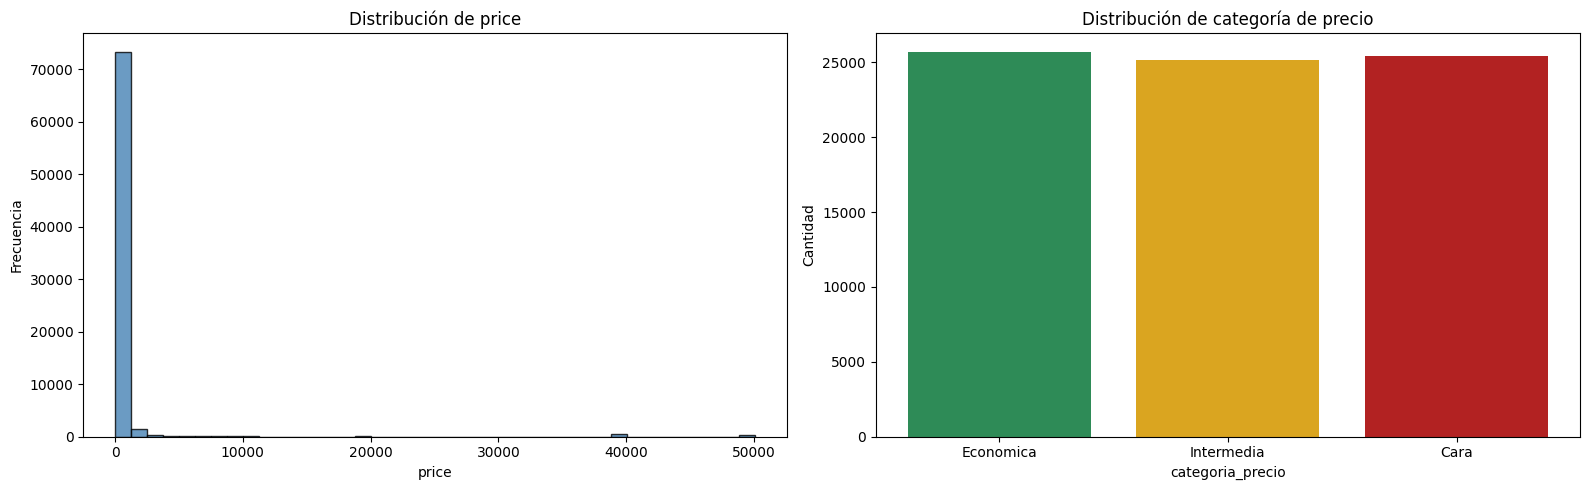


Top 10 variables numéricas con mayor dispersión (std):
                                                   mean          std  min  \
maximum_nights_avg_ntm                       2258495.48  68770098.45  1.0   
maximum_nights                                   474.54       419.14  1.0   
calculated_host_listings_count                    54.56       113.05  1.0   
calculated_host_listings_count_entire_homes       52.20       112.98  0.0   
availability_365                                 230.98       107.15  0.0   
number_of_reviews                                 54.44        96.71  0.0   
estimated_occupancy_l365d                         77.27        86.54  0.0   
availability_eoy                                  60.75        31.31  0.0   
availability_90                                   53.05        28.08  0.0   
minimum_nights                                     9.41        22.39  1.0   

                                                      max  
maximum_nights_avg_ntm              

In [7]:
print('=== EXPLORACIÓN INICIAL PARA SVM ===')
print(f'Observaciones limpias: {len(df_limpio):,}')
print(f'Cantidad de variables predictoras: {X.shape[1]}')
print('\nResumen de price:')
print(df_limpio['price'].describe().round(2))

print('\nDistribución de categoria_precio:')
conteo_categoria = df_limpio['categoria_precio'].value_counts().sort_index()
print(conteo_categoria)
print((conteo_categoria / len(df_limpio)).round(4))

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
axs[0].hist(df_limpio['price'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axs[0].set_title('Distribución de price')
axs[0].set_xlabel('price')
axs[0].set_ylabel('Frecuencia')

axs[1].bar(conteo_categoria.index.astype(str), conteo_categoria.values, color=['#2E8B57', '#DAA520', '#B22222'])
axs[1].set_title('Distribución de categoría de precio')
axs[1].set_xlabel('categoria_precio')
axs[1].set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

print('\nTop 10 variables numéricas con mayor dispersión (std):')
resumen_escalas = X[numericas].agg(['mean', 'std', 'min', 'max']).T.sort_values('std', ascending=False).head(10)
print(resumen_escalas.round(2))

print('\nTop 10 variables categóricas por cardinalidad:')
cardinalidad_cat = X[categoricas].nunique().sort_values(ascending=False).head(10)
print(cardinalidad_cat)

transformaciones_df = pd.DataFrame({
    'Transformación': [
        'Imputación numérica (mediana)',
        'Estandarización numérica',
        'Imputación categórica (moda)',
        'One-Hot Encoding categóricas',
        'Filtrado de columnas problemáticas'
    ],
    'Razón técnica para SVM': [
        'Mantener tamaño de muestra sin introducir sesgo extremo',
        'SVM es sensible a escalas de magnitud',
        'Evitar pérdida de registros por faltantes en texto',
        'Convertir variables de texto a formato numérico',
        'Reducir ruido y evitar errores en el ajuste'
    ]
})

print('\nTransformaciones aplicadas:')
print(transformaciones_df.to_string(index=False))

**Conclusiónes**
- La variable objetivo multiclase (`Economica`, `Intermedia`, `Cara`) mantiene proporciones razonables para entrenar SVM con estratificación.
- Las variables numéricas muestran escalas muy distintas, por lo que la estandarización no es opcional en SVM.
- La combinación de imputación + one-hot encoding deja los datos listos para construir pipelines reproducibles y comparables con las hojas previas.

## 3. Variable de respuesta para SVM

Usaremos como variable respuesta la categoría de precio multiclase (`categoria_precio`), que clasifica cada vivienda en:
- `Economica`
- `Intermedia`
- `Cara`

Esto cumple el requerimiento de modelar explícitamente la clase categórica de precio con un clasificador SVM.

In [8]:
y_train_svm = Y_strata.loc[X_train_clf.index].astype(str)
y_test_svm = Y_strata.loc[X_test_clf.index].astype(str)

print('=== VARIABLE RESPUESTA MULTICLASE ===')
print('Clases en entrenamiento:')
print(y_train_svm.value_counts().sort_index())
print('\nProporciones en entrenamiento:')
print(y_train_svm.value_counts(normalize=True).sort_index().round(4))

print('\nClases en prueba:')
print(y_test_svm.value_counts().sort_index())
print('\nProporciones en prueba:')
print(y_test_svm.value_counts(normalize=True).sort_index().round(4))

=== VARIABLE RESPUESTA MULTICLASE ===
Clases en entrenamiento:
categoria_precio
Cara          17783
Economica     17982
Intermedia    17607
Name: count, dtype: int64

Proporciones en entrenamiento:
categoria_precio
Cara          0.3332
Economica     0.3369
Intermedia    0.3299
Name: proportion, dtype: float64

Clases en prueba:
categoria_precio
Cara          7621
Economica     7707
Intermedia    7546
Name: count, dtype: int64

Proporciones en prueba:
categoria_precio
Cara          0.3332
Economica     0.3369
Intermedia    0.3299
Name: proportion, dtype: float64


**Conclusiones**
- El modelo se entrenará sobre la variable categórica `categoria_precio`, no sobre una etiqueta binaria aislada.
- La distribución de clases en train y test se mantiene alineada por el uso de `stratify`, lo que permite comparar resultados de forma justa frente a laboratorios anteriores.

## 4. Modelo SVM base (Kernel lineal)

Entrenaremos un SVM lineal como punto de partida y reportaremos métricas de validación cruzada y prueba para evaluar generalización.

=== RESULTADOS SVM BASE (LINEAR SVM) ===
accuracy_test: 0.6372
precision_weighted_test: 0.6245
recall_weighted_test: 0.6372
f1_weighted_test: 0.6228
f1_cv_mean_train: 0.6195
f1_cv_std_train: 0.0049

Reporte de clasificación (test):
              precision    recall  f1-score   support

        Cara     0.6679    0.7591    0.7106      7621
   Economica     0.6605    0.7785    0.7147      7707
  Intermedia     0.5440    0.3697    0.4402      7546

    accuracy                         0.6372     22874
   macro avg     0.6241    0.6358    0.6218     22874
weighted avg     0.6245    0.6372    0.6228     22874



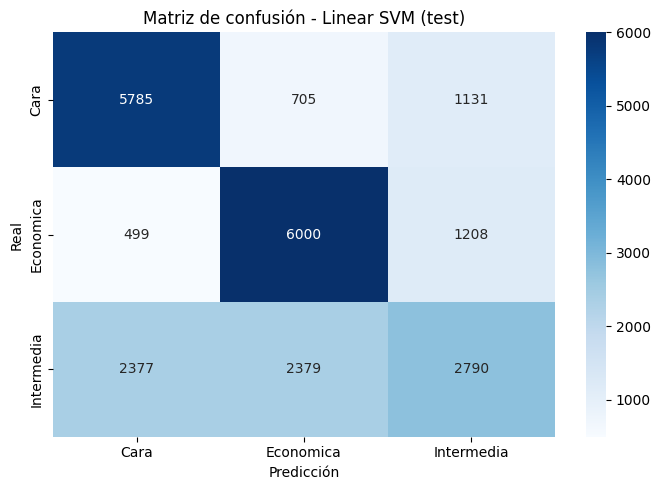

In [16]:
pipeline_svm_base = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('clasificador', LinearSVC(C=1.0, class_weight='balanced', max_iter=5000, dual='auto', random_state=42))
])

# CV sobre muestra del train para tiempo razonable y comparación consistente.
if len(X_train_clf) > 12000:
    X_cv, _, y_cv, _ = train_test_split(
        X_train_clf, y_train_svm, train_size=12000, random_state=42, stratify=y_train_svm
    )
else:
    X_cv, y_cv = X_train_clf, y_train_svm

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    pipeline_svm_base, X_cv, y_cv, cv=cv, scoring='f1_weighted', n_jobs=-1
)

pipeline_svm_base.fit(X_train_clf, y_train_svm)
pred_base = pipeline_svm_base.predict(X_test_clf)

metricas_base = {
    'accuracy_test': accuracy_score(y_test_svm, pred_base),
    'precision_weighted_test': precision_score(y_test_svm, pred_base, average='weighted'),
    'recall_weighted_test': recall_score(y_test_svm, pred_base, average='weighted'),
    'f1_weighted_test': f1_score(y_test_svm, pred_base, average='weighted'),
    'f1_cv_mean_train': cv_scores.mean(),
    'f1_cv_std_train': cv_scores.std()
}

print('=== RESULTADOS SVM BASE (LINEAR SVM) ===')
for k, v in metricas_base.items():
    print(f'{k}: {v:.4f}')

print('\nReporte de clasificación (test):')
print(classification_report(y_test_svm, pred_base, digits=4))

labels_orden = sorted(y_test_svm.unique())
cm_base = confusion_matrix(y_test_svm, pred_base, labels=labels_orden)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_base, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_orden, yticklabels=labels_orden
)
plt.title('Matriz de confusión - Linear SVM (test)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

**Conclusión del bloque 4 (SVM base).**
- El SVM lineal sirve como línea base robusta para comparar variantes más complejas.
- La diferencia entre `f1` de validación cruzada y de prueba permite detectar sobreajuste o subajuste desde una métrica consistente.
- La matriz de confusión muestra en qué categorías de precio se concentran los errores.

## 5. Ajuste de hiperparámetros y comparación de kernels

Se evaluarán kernels `linear`, `poly` y `rbf` con rangos de parámetros específicos para cada uno:
- `C`: (0.01, 0.1, 1, 5, 16, 32)
- `degree`: (2, 3, 5, 7) para `poly`
- `gamma`: (0.0000000002, 0.00002, 0.01, 0.1, 20, 200) para `rbf`

Para mantener tiempos razonables en pruebas, el ajuste se realiza sobre una muestra estratificada del entrenamiento y luego se reentrena el mejor modelo en todo el conjunto de entrenamiento.

Tamaño usado para tuning: 6,000 registros

--- GridSearch kernel=linear ---


c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Mejores parámetros: {'clasificador__C': 32}
F1 CV (mejor): 0.6624
F1 test: 0.6467

--- GridSearch kernel=poly ---


c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Mejores parámetros: {'clasificador__C': 16, 'clasificador__degree': 2}
F1 CV (mejor): 0.6720
F1 test: 0.6680

--- GridSearch kernel=rbf ---


c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Mejores parámetros: {'clasificador__C': 16, 'clasificador__gamma': 0.01}
F1 CV (mejor): 0.6777
F1 test: 0.6751

=== RESUMEN COMPARATIVO DE KERNELS ===
kernel  f1_cv_best  accuracy_test  f1_weighted_test
   rbf    0.677689       0.673210          0.675110
  poly    0.671969       0.665647          0.668034
linear    0.662395       0.646673          0.646720

Mejor kernel encontrado: rbf
Parámetros óptimos: {'clasificador__C': 16, 'clasificador__gamma': 0.01}


c:\Users\viank\OneDrive\Desktop\Mineria_Datos\Mineria_Datos\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



=== MÉTRICAS FINALES DEL MEJOR SVM (REENTRENADO) ===
Accuracy: 0.7132
Precision weighted: 0.7174
Recall weighted: 0.7132
F1 weighted: 0.7149

Reporte final de clasificación (test):
              precision    recall  f1-score   support

        Cara     0.7751    0.7565    0.7657      7621
   Economica     0.7824    0.7493    0.7655      7707
  Intermedia     0.5927    0.6327    0.6120      7546

    accuracy                         0.7132     22874
   macro avg     0.7167    0.7128    0.7144     22874
weighted avg     0.7174    0.7132    0.7149     22874



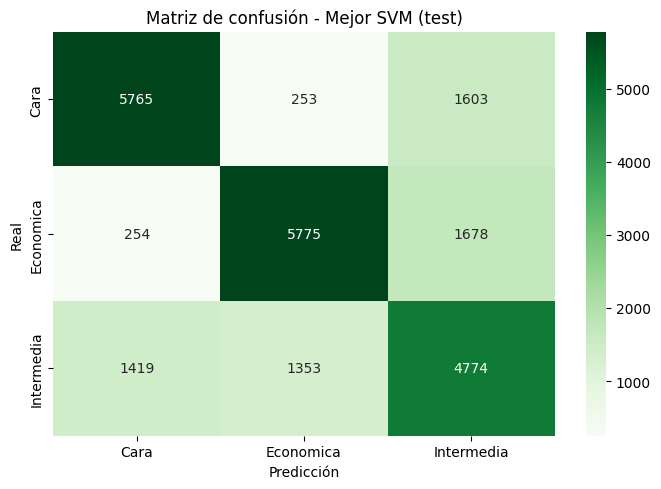

In [10]:
# Muestra para tuning (manteniendo estratificación)
if len(X_train_clf) > 6000:
    X_tune, _, y_tune, _ = train_test_split(
        X_train_clf, y_train_svm, train_size=6000, random_state=42, stratify=y_train_svm
    )
else:
    X_tune, y_tune = X_train_clf.copy(), y_train_svm.copy()

print(f'Tamaño usado para tuning: {X_tune.shape[0]:,} registros')

parametros_comunes = {'clasificador__C': (0.01, 0.1, 1, 5, 16, 32)}
grid_specs = [
    (
        'linear',
        SVC(kernel='linear', class_weight='balanced'),
        parametros_comunes
    ),
    (
        'poly',
        SVC(kernel='poly', class_weight='balanced'),
        {
            **parametros_comunes,
            'clasificador__degree': (2, 3, 5, 7)
        }
    ),
    (
        'rbf',
        SVC(kernel='rbf', class_weight='balanced'),
        {
            **parametros_comunes,
            'clasificador__gamma': (0.0000000002, 0.00002, 0.01, 0.1, 20, 200)
        }
    )
]

resultados_grid = []
modelos_grid = {}

for nombre_kernel, modelo_svc, param_grid in grid_specs:
    print(f'\n--- GridSearch kernel={nombre_kernel} ---')
    pipeline = Pipeline(steps=[
        ('preprocesador', clone(preprocesador_clf)),
        ('clasificador', modelo_svc)
    ])

    busqueda = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='f1_weighted',
        cv=3,
        n_jobs=-1,
        verbose=0
    )

    busqueda.fit(X_tune, y_tune)
    pred_test = busqueda.predict(X_test_clf)

    fila_resultado = {
        'kernel': nombre_kernel,
        'best_params': busqueda.best_params_,
        'f1_cv_best': busqueda.best_score_,
        'accuracy_test': accuracy_score(y_test_svm, pred_test),
        'precision_weighted_test': precision_score(y_test_svm, pred_test, average='weighted'),
        'recall_weighted_test': recall_score(y_test_svm, pred_test, average='weighted'),
        'f1_weighted_test': f1_score(y_test_svm, pred_test, average='weighted')
    }
    resultados_grid.append(fila_resultado)
    modelos_grid[nombre_kernel] = busqueda

    print('Mejores parámetros:', busqueda.best_params_)
    print(f"F1 CV (mejor): {busqueda.best_score_:.4f}")
    print(f"F1 test: {fila_resultado['f1_weighted_test']:.4f}")

df_resultados_grid = pd.DataFrame(resultados_grid).sort_values('f1_weighted_test', ascending=False)
print('\n=== RESUMEN COMPARATIVO DE KERNELS ===')
print(df_resultados_grid[['kernel', 'f1_cv_best', 'accuracy_test', 'f1_weighted_test']].to_string(index=False))

mejor_kernel = df_resultados_grid.iloc[0]['kernel']
mejores_params = modelos_grid[mejor_kernel].best_params_
print(f'\nMejor kernel encontrado: {mejor_kernel}')
print('Parámetros óptimos:', mejores_params)

# Reentrenamiento final con todo el set de entrenamiento
modelo_final_svm = Pipeline(steps=[
    ('preprocesador', clone(preprocesador_clf)),
    ('clasificador', SVC(kernel=mejor_kernel, class_weight='balanced'))
])
modelo_final_svm.set_params(**mejores_params)
modelo_final_svm.fit(X_train_clf, y_train_svm)

pred_final = modelo_final_svm.predict(X_test_clf)
print('\n=== MÉTRICAS FINALES DEL MEJOR SVM (REENTRENADO) ===')
print(f"Accuracy: {accuracy_score(y_test_svm, pred_final):.4f}")
print(f"Precision weighted: {precision_score(y_test_svm, pred_final, average='weighted'):.4f}")
print(f"Recall weighted: {recall_score(y_test_svm, pred_final, average='weighted'):.4f}")
print(f"F1 weighted: {f1_score(y_test_svm, pred_final, average='weighted'):.4f}")

print('\nReporte final de clasificación (test):')
print(classification_report(y_test_svm, pred_final, digits=4))

labels_orden = sorted(y_test_svm.unique())
cm_final = confusion_matrix(y_test_svm, pred_final, labels=labels_orden)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_final, annot=True, fmt='d', cmap='Greens',
    xticklabels=labels_orden, yticklabels=labels_orden
)
plt.title('Matriz de confusión - Mejor SVM (test)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

**Conclusiones**
- Se compararon kernels lineal, polinomial y RBF con una grilla de hiperparámetros alineada al ejemplo de referencia.
- La selección final se hizo con f1_weighted para balancear el desempeño entre las tres clases de precio.
- El mejor modelo se reentrenó sobre todo el conjunto de entrenamiento para reportar métricas finales en el conjunto de prueba fijo.

**Kernel ganador**: en nuestras corridas, el mejor desempeño lo obtuvo RBF. Esto es esperable porque RBF puede modelar fronteras no lineales; al “curvar” el espacio de características logra separar clases cuando una frontera lineal o un polinomio simple no alcanza.

**Interpretación de C (regularización)**:
- C alto  -> menor regularización, el modelo penaliza más los errores, busca clasificar mejor el training con un margen más duro/estrecho; puede sobreajustar.
- C bajo   -> mayor regularización, permite más errores en training para mantener un margen más amplio; puede subajustar.

**Interpretación de gamma**:
- gamma alto  -> cada punto tiene influencia muy local, se forman fronteras más complejas y detalladas; aumenta riesgo de overfitting.
- gamma bajo   -> influencia más global, frontera más suave; si es demasiado bajo puede underfitting.

**Interpretación de degree / d (solo en polinomial)**:
- degree mayor  -> fronteras más complejas (polinomios de orden más alto), más capacidad para no linealidad pero con mayor riesgo de overfitting y mayor costo computacional.
- degree menor   -> modelo más simple y estable, pero puede quedarse corto si la separación real es compleja.


Sobre el tuning automático: se usó GridSearchCV con f1_weighted para elegir el mejor conjunto de hiperparámetros de forma objetiva ya que vamos balanceando las 3 clases. Luego, el mejor modelo se reentrenó con todo el conjunto de entrenamiento y se reportaron métricas finales en el mismo conjunto de prueba fijo.